# **Rep 4. Checkpoint 1. Payoff diagrams**
### Paola Figueroa
### 29/marzo/2026

## **Instruciones**
- Obtén dinámicamente los precios mid del call y put con strike K = 680 y vencimiento 2026-04-17:
- Con esos valores, genera:
    - El plot 2×2 de las cuatro posiciones básicas con P&L neto
    - La comparación de payoff bruto vs. P&L neto para el call y el put por separado
    - Una tabla con los break-evens de las cuatro posiciones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd

## **Precios mid dinámicos**

In [2]:
tk  = yf.Ticker('SPY')
S0  = tk.fast_info['last_price']
exp = '2026-04-17'
K   = 680

calls = tk.option_chain(exp).calls
puts  = tk.option_chain(exp).puts

row_call = calls[calls['strike'] == K].iloc[0]
row_put  = puts[puts['strike'] == K].iloc[0]

C = (row_call['bid'] + row_call['ask']) / 2
P = (row_put['bid']  + row_put['ask'])  / 2

print(f"S0={S0:.2f}  K={K}  C={C:.4f}  P={P:.4f}")

S0=634.09  K=680  C=0.9950  P=46.6250


## **Opciones básicas con P&L neto**

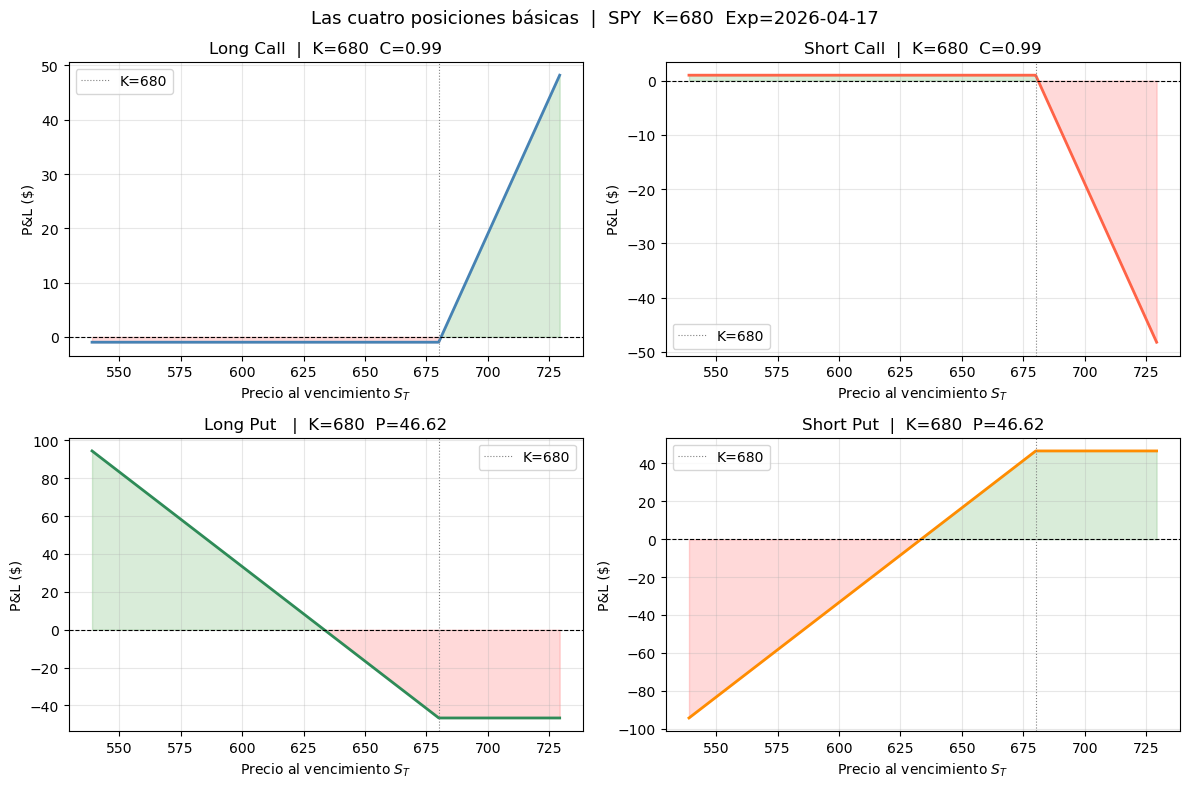

In [3]:
S_range = np.linspace(S0 * 0.85, S0 * 1.15, 500)  # rango centrado en S0

# Payoffs brutos
call_long_bruto  =  np.maximum(S_range - K, 0)
call_short_bruto = -np.maximum(S_range - K, 0)
put_long_bruto   =  np.maximum(K - S_range, 0)
put_short_bruto  = -np.maximum(K - S_range, 0)

# P&L neto (descontando la prima pagada/cobrada)
pnl_call_long  = call_long_bruto  - C
pnl_call_short = call_short_bruto + C
pnl_put_long   = put_long_bruto   - P
pnl_put_short  = put_short_bruto  + P

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

configs = [
    (axes[0,0], pnl_call_long,  f'Long Call  |  K={K}  C={C:.2f}',  'steelblue'),
    (axes[0,1], pnl_call_short, f'Short Call  |  K={K}  C={C:.2f}', 'tomato'),
    (axes[1,0], pnl_put_long,   f'Long Put   |  K={K}  P={P:.2f}',  'seagreen'),
    (axes[1,1], pnl_put_short,  f'Short Put  |  K={K}  P={P:.2f}',  'darkorange'),
]

for ax, pnl, title, color in configs:
    ax.plot(S_range, pnl, color=color, linewidth=2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(K, color='gray',  linewidth=0.8, linestyle=':', label=f'K={K}')
    ax.fill_between(S_range, pnl, 0, where=(pnl > 0), alpha=0.15, color='green')
    ax.fill_between(S_range, pnl, 0, where=(pnl < 0), alpha=0.15, color='red')
    ax.set_title(title)
    ax.set_xlabel('Precio al vencimiento $S_T$')
    ax.set_ylabel('P&L ($)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Las cuatro posiciones básicas  |  SPY  K={K}  Exp={exp}', fontsize=13)
plt.tight_layout()
plt.show()

## **Payoff bruto vs P&L neto para Call y Put por separado**

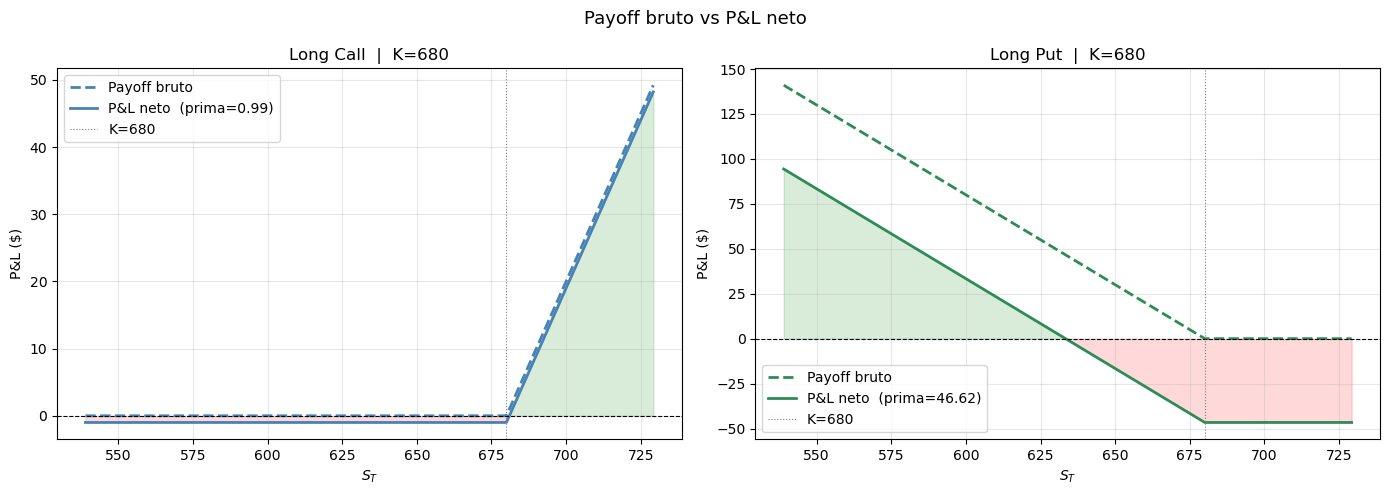

In [4]:
plt.close('all')  # limpia figuras anteriores

plt.figure(figsize=(14, 5))

# Call
plt.subplot(121)
plt.plot(S_range, call_long_bruto,
         label='Payoff bruto', color='steelblue', linewidth=2, linestyle='--')
plt.plot(S_range, pnl_call_long,
         label=f'P&L neto  (prima={C:.2f})', color='steelblue', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(K, color='gray',  linewidth=0.8, linestyle=':', label=f'K={K}')
plt.fill_between(S_range, pnl_call_long, 0, where=(pnl_call_long > 0),
                 alpha=0.15, color='green')
plt.fill_between(S_range, pnl_call_long, 0, where=(pnl_call_long < 0),
                 alpha=0.15, color='red')
plt.title(f'Long Call  |  K={K}')
plt.xlabel('$S_T$')
plt.ylabel('P&L ($)')
plt.legend()
plt.grid(True, alpha=0.3)

# Put
plt.subplot(122)
plt.plot(S_range, put_long_bruto,
         label='Payoff bruto', color='seagreen', linewidth=2, linestyle='--')
plt.plot(S_range, pnl_put_long,
         label=f'P&L neto  (prima={P:.2f})', color='seagreen', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(K, color='gray',  linewidth=0.8, linestyle=':', label=f'K={K}')
plt.fill_between(S_range, pnl_put_long, 0, where=(pnl_put_long > 0),
                 alpha=0.15, color='green')
plt.fill_between(S_range, pnl_put_long, 0, where=(pnl_put_long < 0),
                 alpha=0.15, color='red')
plt.title(f'Long Put  |  K={K}')
plt.xlabel('$S_T$')
plt.ylabel('P&L ($)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('Payoff bruto vs P&L neto', fontsize=13)
plt.tight_layout()
plt.show()


## **Tabla de Break Evens**

In [5]:
be_call_long  = K + C
be_call_short = K + C
be_put_long   = K - P
be_put_short  = K - P

tabla = pd.DataFrame({
    'Posición'    : ['Long Call', 'Short Call', 'Long Put', 'Short Put'],
    'K'           : [K, K, K, K],
    'Prima'       : [C, C, P, P],
    'Break-even'  : [be_call_long, be_call_short, be_put_long, be_put_short],
    'Ganancia si…': [
        f'S_T > {be_call_long:.2f}',
        f'S_T < {be_call_short:.2f}',
        f'S_T < {be_put_long:.2f}',
        f'S_T > {be_put_short:.2f}',
    ]
})

print(tabla.to_string(index=False))

  Posición   K  Prima  Break-even Ganancia si…
 Long Call 680  0.995     680.995 S_T > 681.00
Short Call 680  0.995     680.995 S_T < 681.00
  Long Put 680 46.625     633.375 S_T < 633.38
 Short Put 680 46.625     633.375 S_T > 633.38


## **Preguntas**

- Con el S0 actual, ¿cuál de las cuatro posiciones básicas tiene el break-even más cercano al precio actual? ¿Qué implica eso?
    - Tomando en cuenta los resultados de la tabla anterior, restamos ese valor menos el S0 de 634, la Long Put y la Short Put ganan esta por mucho: su break-even está a solo 0.71 puntos del precio actual. Están muy cerca porque el put con K=680 está deep in-the-money, lo que implica que el SPY cotiza en 634, que está bastante por debajo del strike. Eso hace que la prima ($46.625) sea casi puro valor intrínseco (680 − 634 = 45.91), quedando muy poco valor temporal. En la práctica, esto implica que si compras el put (long put), básicamente ya estás ganando porque cualquier caída adicional de SPY es ganancia directa. Por el otro lado, si vendes el put (short put), estamos viviendo al límite: con que SPY caiga 71 centavos más, ya estás en pérdida.

- Si SPY termina exactamente en K al vencimiento, ¿cuánto gana o pierde cada posición? ¿Por qué?
    - Cuando el precio cierra justo en el strike, ninguna opción tiene valor intrínseco porque el call da derecho a comprar a 680 cuando el mercado vale 680, y el put da derecho a vender a 680 cuando el mercado vale 680. En ambos casos, ejercer o no ejercer da exactamente lo mismo, así que el payoff bruto es cero. Lo que sí queda es la prima que a pagar o cobrar al abrir la posición. Los compradores (long call y long put) pierden su prima completa porque gastaron dinero por una opción que al final no valió nada. Los vendedores (short call y short put) se quedan con toda la prima cobrada porque la opción que vendieron expiró sin valor. El mejor caso el long put: para que SPY llegue a $680 desde donde está hoy ($634), tendría que subir un 7.2%. Si eso pasa y mantienes el put hasta vencimiento, pierdes los $46.625 de prima completos, sin importar que el mercado haya hecho exactamente lo contrario de lo que esperabas. Esa es la realidad de comprar opciones: si te equivocas de dirección, pagas el precio completo de haberte equivocado.

- Compara la pérdida máxima de una long call vs. una short put. ¿Cuál tiene más riesgo? ¿Por qué?
    - La long call tiene pérdida máxima de menos de un dólar (pagas muy poca prima porque el call está deep out-of-the-money (K=680 con SPY en 634). Lo peor que puede pasar es perder $0.995). La short put, en cambio, es otra historia. Cobra $46.625 de prima, pero si SPY sigue cayendo,  estaríamos obligados a comprar las acciones a $680 sin importar el precio de mercado. La relación riesgo/retorno es muy desfavorable: cobras ~$47 pero puedes perder cientos.

    
- ¿En qué escenario de mercado elegirías una long put sobre una short call, si ambas expresan una visión bajista?
    - Aunque las dos expresan una visión bajista, son muy distintas en riesgo.Con la long put pagas $46.625 de prima y obtienes una posición que ya está ITM; si SPY sigue cayendo, ganas punto a punto. Lo peor que puede pasar es perder esa prima, por lo que tenemos un riesgo definido con ganancia proporcional a lo que decidas. Con la short call cobras apenas $0.995 y te quedas con riesgo ilimitado al alza. Si SPY rebota por encima de $681, las pérdidas no tienen techo y todo eso a cambio de menos de un dólar de prima. La relación riesgo/retorno es muy desfavorable.
    En este escenario, la long put es claramente la mejor herramienta bajista: ya tiene valor intrínseco, el riesgo está acotado y si la volatilidad sube, tu opción vale más incluso sin que SPY se mueva.